In [37]:
import math
from typing import Tuple

import torch
import torchaudio
from matplotlib import pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader


# ----------------------------s--------------------------
# 1. 장난감 오디오 데이터셋
# ------------------------------------------------------
class ToySineWaveDataset(Dataset):
    """
    저역 / 중역 / 고역의 사인파 + 노이즈로 구성된 장난감 오디오 데이터셋.

    각 샘플:
      - wave: (T,) float 텐서, 샘플링 레이트 sample_rate, 길이 duration_sec
      - label: 0(저역), 1(중역), 2(고역)
    """

    def __init__(
        self,
        num_samples: int = 300,
        sample_rate: int = 16_000,
        duration_sec: float = 1.0,
        noise_std: float = 0.01,
    ):
        super().__init__()
        self.num_samples = num_samples
        self.sample_rate = sample_rate
        self.duration_sec = duration_sec
        self.noise_std = noise_std

        self.signal_length = int(sample_rate * duration_sec)

        # 각 클래스별 주파수 범위
        self.freq_ranges = {
            0: (200.0, 400.0),  # 저역
            1: (800.0, 1200.0),  # 중역
            2: (2500.0, 3500.0),  # 고역
        }

    def __len__(self):
        return self.num_samples

    def _generate_sine(self, freq: float) -> torch.Tensor:
        """
        주어진 주파수의 사인파 생성 (길이 self.signal_length).
        """
        t = torch.arange(self.signal_length) / self.sample_rate  # (T,)
        wave = torch.sin(2.0 * math.pi * freq * t)
        return wave

    def __getitem__(self, idx):
        # 클래스 랜덤 선택
        wave_sum = 0
        for label in self.freq_ranges:
            f_low, f_high = self.freq_ranges[label]
            # 해당 클래스 범위에서 랜덤 주파수 선택
            freq = torch.empty(1).uniform_(f_low, f_high).item()

            # 사인파 생성 + 가우시안 노이즈
            wave = self._generate_sine(freq)
            noise = torch.randn_like(wave) * self.noise_std
            wave = wave + noise

            # 정규화(선택 사항) - 최대 절댓값 1로 스케일링
            max_abs = wave.abs().max().clamp(min=1e-6)
            wave = wave / max_abs
            wave_sum += wave
        # (T,) 텐서를 (1, T)로 만들어서 채널 차원을 추가해줄 수도 있음
        return wave_sum, 0


class FilterAugment(nn.Module):
    """
    FilterAugment: 주파수-의존 랜덤 필터 기반 오디오 데이터 증강

    입력 텐서 형태:
      (..., n_freq, n_time)  # 예: (B, F, T), (B, C, F, T), (F, T)

    Args:
        db_range: 각 주파수 밴드에 적용할 gain(dB) 범위
        n_band_range: 분할할 주파수 밴드 개수 범위 (min, max)
        min_bandwidth: 각 밴드의 최소 주파수 bin 수
        filter_type: "step" 또는 "linear"
        input_in_db: True이면 입력이 dB 스케일이라고 가정하고 additive dB로 적용
        p: 이 augment를 적용할 확률
    """

    def __init__(
        self,
        db_range: Tuple[float, float] = (-7.5, 6.0),
        n_band_range: Tuple[int, int] = (2, 5),
        min_bandwidth: int = 4,
        filter_type: str = "step",
        input_in_db: bool = False,
        p: float = 1.0,
    ):
        super().__init__()
        assert n_band_range[0] >= 1
        assert filter_type in ("step", "linear")

        self.db_range = db_range
        self.n_band_range = n_band_range
        self.min_bandwidth = min_bandwidth
        self.filter_type = filter_type
        self.input_in_db = input_in_db
        self.p = p
        self.filt_db = None

    def _sample_filter_db(
        self, batch_size: int, n_freq: int, device: torch.device
    ) -> torch.Tensor:
        """
        (batch_size, n_freq, 1) 모양의 dB 단위 필터 곡선을 샘플링
        """
        n_band = torch.randint(
            low=self.n_band_range[0],
            high=self.n_band_range[1] + 1,
            size=(1,),
            device=device,
        ).item()

        if n_band <= 0:
            return torch.zeros(batch_size, n_freq, 1, device=device)

        # 각 밴드 최소 폭 보장
        min_bw = min(self.min_bandwidth, max(1, n_freq // n_band))
        max_start = max(0, n_freq - n_band * min_bw)

        if n_band == 1 or max_start == 0:
            boundaries = torch.tensor([0, n_freq], device=device)
        else:
            # 내부 경계들을 랜덤 샘플링하고,
            # 각 밴드에 min_bw만큼 기본 폭을 보장하는 형태로 offset
            inner = (
                torch.sort(
                    torch.randint(0, max_start + 1, (n_band - 1,), device=device)
                )[0]
                + torch.arange(1, n_band, device=device) * min_bw
            )
            boundaries = torch.cat(
                [
                    torch.tensor([0], device=device),
                    inner,
                    torch.tensor([n_freq], device=device),
                ]
            )

        filt_db = torch.zeros(batch_size, n_freq, 1, device=device)

        if self.filter_type == "step":
            # 각 밴드에 하나의 gain(dB)
            gains_db = torch.empty(batch_size, n_band, device=device).uniform_(
                self.db_range[0], self.db_range[1]
            )
            for i in range(n_band):
                f0 = int(boundaries[i].item())
                f1 = int(boundaries[i + 1].item())
                if f1 <= f0:
                    continue
                filt_db[:, f0:f1, 0] = gains_db[:, i].unsqueeze(-1)

        else:  # "linear": 경계마다 gain을 뽑고 선형 보간
            gains_db = torch.empty(batch_size, n_band + 1, device=device).uniform_(
                self.db_range[0], self.db_range[1]
            )
            for i in range(n_band):
                f0 = int(boundaries[i].item())
                f1 = int(boundaries[i + 1].item())
                if f1 <= f0:
                    continue
                pos = torch.linspace(0.0, 1.0, f1 - f0, device=device)  # (f_band,)
                # (batch, 1) * (1-pos) + (batch, 1) * pos  → (batch, f_band)
                band_db = (
                    gains_db[:, i].unsqueeze(1) * (1 - pos)
                    + gains_db[:, i + 1].unsqueeze(1) * pos
                )
                filt_db[:, f0:f1, 0] = band_db

        self.filt_db = filt_db
        return filt_db

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 학습 모드 + 확률 p 조건에서만 적용
        if not self.training or torch.rand(1).item() > self.p:
            return x

        device = x.device
        *batch_dims, n_freq, n_time = x.shape
        batch_size = int(x.numel() // (n_freq * n_time))

        # (..., F, T) → (B_flat, F, T)
        x_flat = x.reshape(batch_size, n_freq, n_time)

        # (B_flat, F, 1) dB 필터 샘플링
        filt_db = self._sample_filter_db(
            batch_size=batch_size, n_freq=n_freq, device=device
        )

        if self.input_in_db:
            # 입력이 log-mel(dB)인 경우: additive dB
            x_flat = x_flat + filt_db
        else:
            # 입력이 amplitude/power인 경우: multiplicative gain
            gain = 10.0 ** (filt_db / 20.0)  # amplitude 기준
            x_flat = x_flat * gain

        # 다시 원래 shape로 복원
        out = x_flat.reshape(*batch_dims, n_freq, n_time)
        return out

In [57]:
# 2) 멜 스펙트로그램 및 dB 변환
mel_spec = torchaudio.transforms.MelSpectrogram(
    sample_rate=16_000,
    n_fft=1024,
    hop_length=320,
    n_mels=64,
)

amp_to_db = torchaudio.transforms.AmplitudeToDB(stype="power")

# 3) FilterAugment 인스턴스 (log-mel dB 기준)
filter_augment = FilterAugment(
    db_range=(-20.0, 20.0),
    n_band_range=(4, 4), # for visualization (2 to 4 is recommended)
    min_bandwidth=4,
    filter_type="linear",
    input_in_db=True,  # log-mel(dB)에 additive dB 적용
    p=0.8,
)


train_dataset = ToySineWaveDataset(
    num_samples=300,
    sample_rate=16_000,
    duration_sec=1.0,
    noise_std=0.01,
)
data_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

wave, label = next(iter(data_loader))

# (B, 1, T)로 채널 차원 추가
wave = wave.unsqueeze(1)  # (B, 1, T)

# 1) mel 스펙트로그램 + dB 변환 (augment 전)
spec = mel_spec(wave)  # (B, 1, F, T_spec), power 스케일
spec_db_before = amp_to_db(spec)  # (B, 1, F, T_spec), dB

# 2) FilterAugment 적용 (augment 후)
spec_db_after = filter_augment(spec_db_before.clone())

# 3) 첫 번째 샘플만 꺼내서 CPU로 가져오기
spec_before_np = spec_db_before[0, 0].detach().cpu().numpy()  # (F, T_spec)
spec_after_np = spec_db_after[0, 0].detach().cpu().numpy()  # (F, T_spec)

T = spec_before_np.shape[-1]
gains = filter_augment.filt_db[0].repeat(1, T).detach().cpu().numpy()

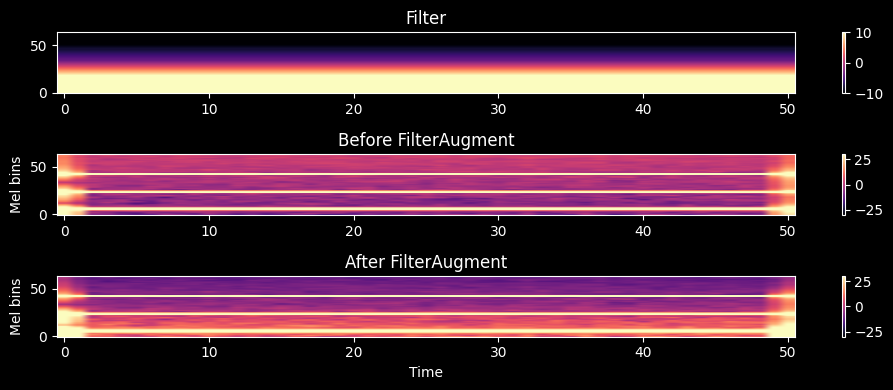

In [60]:
# 4) 시각화
fig, axes = plt.subplots(3, 1, figsize=(10, 4))
im0 = axes[0].imshow(gains, origin="lower", aspect="auto", vmin=-10, vmax=10, cmap="magma")
axes[0].set_title("Filter")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(spec_before_np, origin="lower", aspect="auto", vmin=-30, vmax=30, cmap="magma")
axes[1].set_title("Before FilterAugment")
axes[1].set_ylabel("Mel bins")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(spec_after_np, origin="lower", aspect="auto", vmin=-30, vmax=30, cmap="magma")
axes[2].set_title("After FilterAugment")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Mel bins")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
